<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/Ml_exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nikhil Prasad Fendre

Roll No: CS15

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

## Objectives
- Understand SLR
- Load/preprocess dataset
- Perform EDA
- Compute OLS coefficients
- Evaluate with SSE, MSE, R²
- Visualize regression and residual plots

## Software Requirements
- Python 3.x
- Jupyter/Colab/VS Code
- Libraries: pandas, numpy, matplotlib, seaborn

## Theory
Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

$$
\hat{y} = w_0 + w_1x_1
$$

In matrix form, including the bias/intercept term $X_0$=1:

$$
\hat{y} = Xw
$$

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:

$$
SSE = \sum_{i=1}^{N}(y_i-\hat{y}_i)^2
= (y-Xw)^T(y-Xw)
$$

                    

Solving for w analytically yields the normal equation:

$$
\hat{w} = (X^T X)^{-1}X^T y
$$

###Note:The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("auto-mpg (1).csv")

In [7]:
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [8]:
## Inspect Dataset
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None
              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000   

In [9]:
##  Clean Data
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

print(df.shape)

(392, 9)


In [10]:
## Select Horsepower and MPG
X = df['horsepower'].values
Y = df['mpg'].values

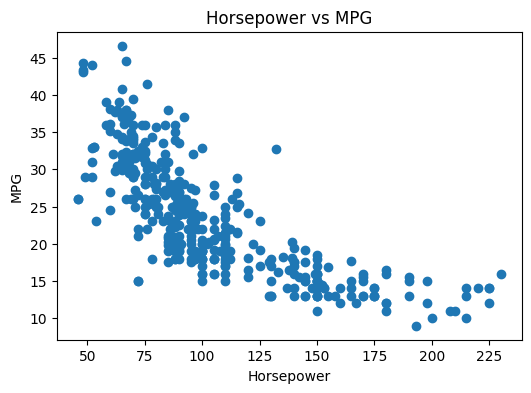

In [11]:
## Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(X, Y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

In [12]:
## Add Bias Term
X_bias = np.c_[np.ones(len(X)), X]

In [13]:
## Compute Correlation
corr = np.corrcoef(X, Y)[0,1]
print("Correlation =", corr)

Correlation = -0.7784267838977756


In [14]:
## Calculate OLS Weights
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept =", weights[0])
print("Slope =", weights[1])

Intercept = 39.9358610211705
Slope = -0.15784473335365387


In [15]:
## Predict Values
Y_pred = X_bias @ weights

print(Y_pred[:10])

[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [16]:
## Residuals
residuals = Y - Y_pred

In [17]:
## Calculate SSE, MSE and R²
SSE = np.sum(residuals**2)
MSE = np.mean(residuals**2)

SST = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SSE / SST)

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


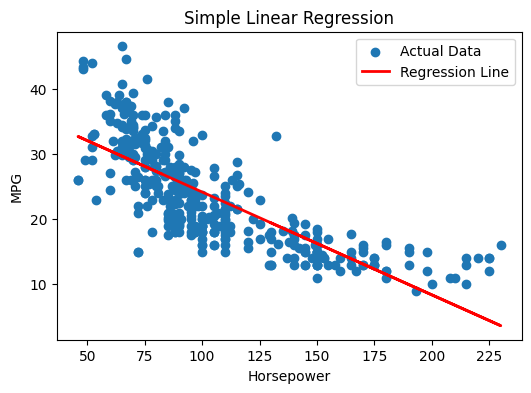

In [18]:
## Regression Line
plt.figure(figsize=(6,4))
plt.scatter(X, Y, label="Actual Data")
plt.plot(X, Y_pred, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

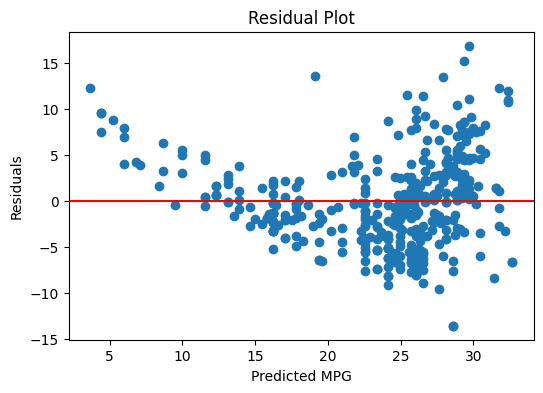

In [19]:
## Residual Plot
plt.figure(figsize=(6,4))
plt.scatter(Y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Interpretation of Results

The scatter plot shows a clear negative linear relationship between **horsepower** and **MPG (Miles Per Gallon)**. As the horsepower of a vehicle increases, its fuel efficiency (MPG) generally decreases. The Simple Linear Regression model successfully captured this relationship using the Ordinary Least Squares (OLS) method. The regression line closely follows the trend of the data, while the residual plot indicates that the prediction errors are randomly distributed around zero, suggesting that the linear model is appropriate. The calculated SSE and MSE values measure the prediction error, and the R² value indicates how well the model explains the variation in MPG. Overall, the model provides a reasonable prediction of MPG based on horsepower.




## Conclusion
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
